In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from matplotlib.cm import get_cmap
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import Normalize
from matplotlib.collections import LineCollection
import tensorflow as tf
from tensorflow.keras import layers, models

In [2]:
# ---------------------------------------
# 1) Trenutna mapa
# ---------------------------------------
cwd = os.getcwd()
print("Trenutna delovna mapa:", cwd)

data_dir = os.path.join(cwd, "DataK")
print("Nalaganje podatkov iz:", data_dir)


def theta_time_evolution(theta0, C, D=10 * 1e-6, dt=5 * 1e-6, num_timesteps=240000, nth_step_save=600):
    """
    Calculates time evolution (relaxation) of director profile (given by angle theta).

    :param theta0: Starting profile of theta (array of length N)
    :param C: Relaxation constant K/gamma
    :param D: Thickness of the layer in meters
    :param dt: Timestep in seconds
    :param num_timesteps: Number of timesteps in the simulation
    :param nth_step_save: Save theta profile at every nth step (number of saves: M = num_timesteps // nth_step_save)
    :return: Time evolution of theta (array of dimensions (M, N))
    """

    N = len(theta0)
    dz = D / (N - 1)
    cnst = C * dt / (dz ** 2)

    if cnst > 0.5:
        print(cnst)
        raise ValueError("Iteration step too large, try smaller timestep or change other parameters.")

    thetas_out = np.zeros((num_timesteps // nth_step_save, N))
    theta1 = np.copy(theta0)
    for t in range(num_timesteps):
        theta1[1:N-1] += cnst * (theta1[2:N] - 2 * theta1[1:N-1] + theta1[:N-2])
        if t % nth_step_save == 0:
            thetas_out[t // nth_step_save, :] = theta1

    return thetas_out


# ---------------------------------------
# 2) Nalaganje podatkov
# ---------------------------------------
K = np.load(os.path.join(data_dir, "Kvalues.npy"))
theta0 = np.load(os.path.join(data_dir, "theta0.npy"))
I = np.load(os.path.join(data_dir, "intensity505noise0.npy"))

Trenutna delovna mapa: /home/jurij/Documents/Faks/PSUF/nal_3
Nalaganje podatkov iz: /home/jurij/Documents/Faks/PSUF/nal_3/DataK



Oblike podatkov:
  intensity: (100000, 400)
  theta0: (100000, 200)
  Kvalues: (100000,)
  primer K (0–10): [1.26669638e-11 1.38111659e-11 1.53952465e-12 1.70329187e-12
 1.33652498e-11 2.90001221e-12 6.71652065e-12 3.15231169e-14
 2.70042515e-12 9.40525096e-12]


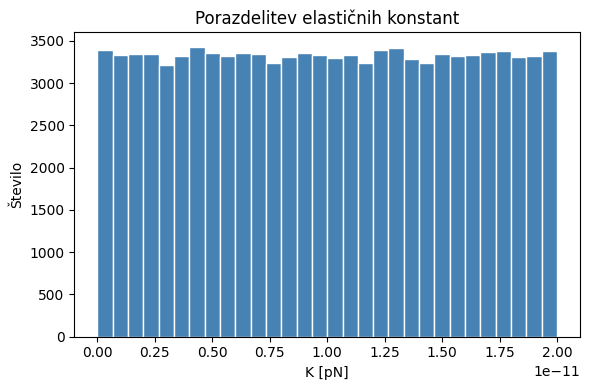

In [3]:
nt = I.shape[1]   # 400 časovnih točk
T = 1.2
times = np.linspace(0, T, nt)

print("\nOblike podatkov:")
print("  intensity:", I.shape)
print("  theta0:", theta0.shape)
print("  Kvalues:", K.shape)
print("  primer K (0–10):", K[:10])

# ---------------------------------------
# 3) Histogram elastičnih konstant
# ---------------------------------------
plt.figure(figsize=(6,4))
plt.hist(K, bins=30, color="steelblue", edgecolor="white")
plt.xlabel("K [pN]")
plt.ylabel("Število")
plt.title("Porazdelitev elastičnih konstant")
plt.tight_layout()
plt.savefig(os.getcwd() + "/figs/K_por.pdf", format="pdf", bbox_inches="tight")
plt.show()

Loaded:
  I: (100000, 400)
  K: (100000,)
  theta0: (100000, 200)

Izbrani indeksi in K:
  index 40493 → K=1.94e-18
  index 41 → K=1.6e-13
  index 14 → K=9.67e-14
  index 12 → K=1.42e-11
  index 32 → K=1.58e-11
  index 41729 → K=2e-11


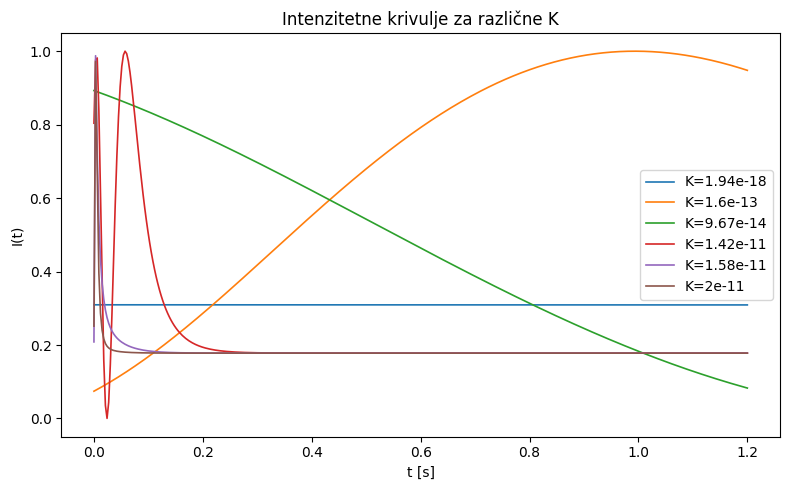

In [4]:
nt = I.shape[1]
T = 1.2
times = np.linspace(0, T, nt)

print("Loaded:")
print("  I:", I.shape)
print("  K:", K.shape)
print("  theta0:", theta0.shape)

# -----------------------------
# 2) Izberemo značilne primere K
# -----------------------------
# zelo majhni -> srednji -> veliki K
indices = [
    np.argmin(K),                                 # najmanjši K
    np.where(K < np.percentile(K, 5))[0][5],      # zelo majhen K
    np.where(K < np.percentile(K, 25))[0][5],     # nižji K
    np.where(K > np.percentile(K, 50))[0][5],     # srednji K
    np.where(K > np.percentile(K, 75))[0][5],     # večji K
    np.argmax(K)                                  # največji K
]

print("\nIzbrani indeksi in K:")
for idx in indices:
    print(f"  index {idx} → K={K[idx]:.3g}")

# -----------------------------
# 3) INTENZITETNI PROFILI I(t)
# -----------------------------
plt.figure(figsize=(8,5))
for idx in indices:
    plt.plot(times, I[idx], lw=1.2, label=f"K={K[idx]:.3g}")
plt.xlabel("t [s]")
plt.ylabel("I(t)")
plt.title("Intenzitetne krivulje za različne K")
plt.legend()
plt.tight_layout()

plt.savefig(os.getcwd() + "/figs/Int_raz_K.pdf", format="pdf", bbox_inches="tight")
plt.show()


Chosen K values:
  idx 40493: K = 1.94e-18
  idx 124: K = 3.98e-13
  idx 16: K = 1.26e-11
  idx 22: K = 1.17e-11
  idx 54: K = 1.92e-11
  idx 41729: K = 2e-11


/tmp/ipykernel_5837/1797598075.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("cool")


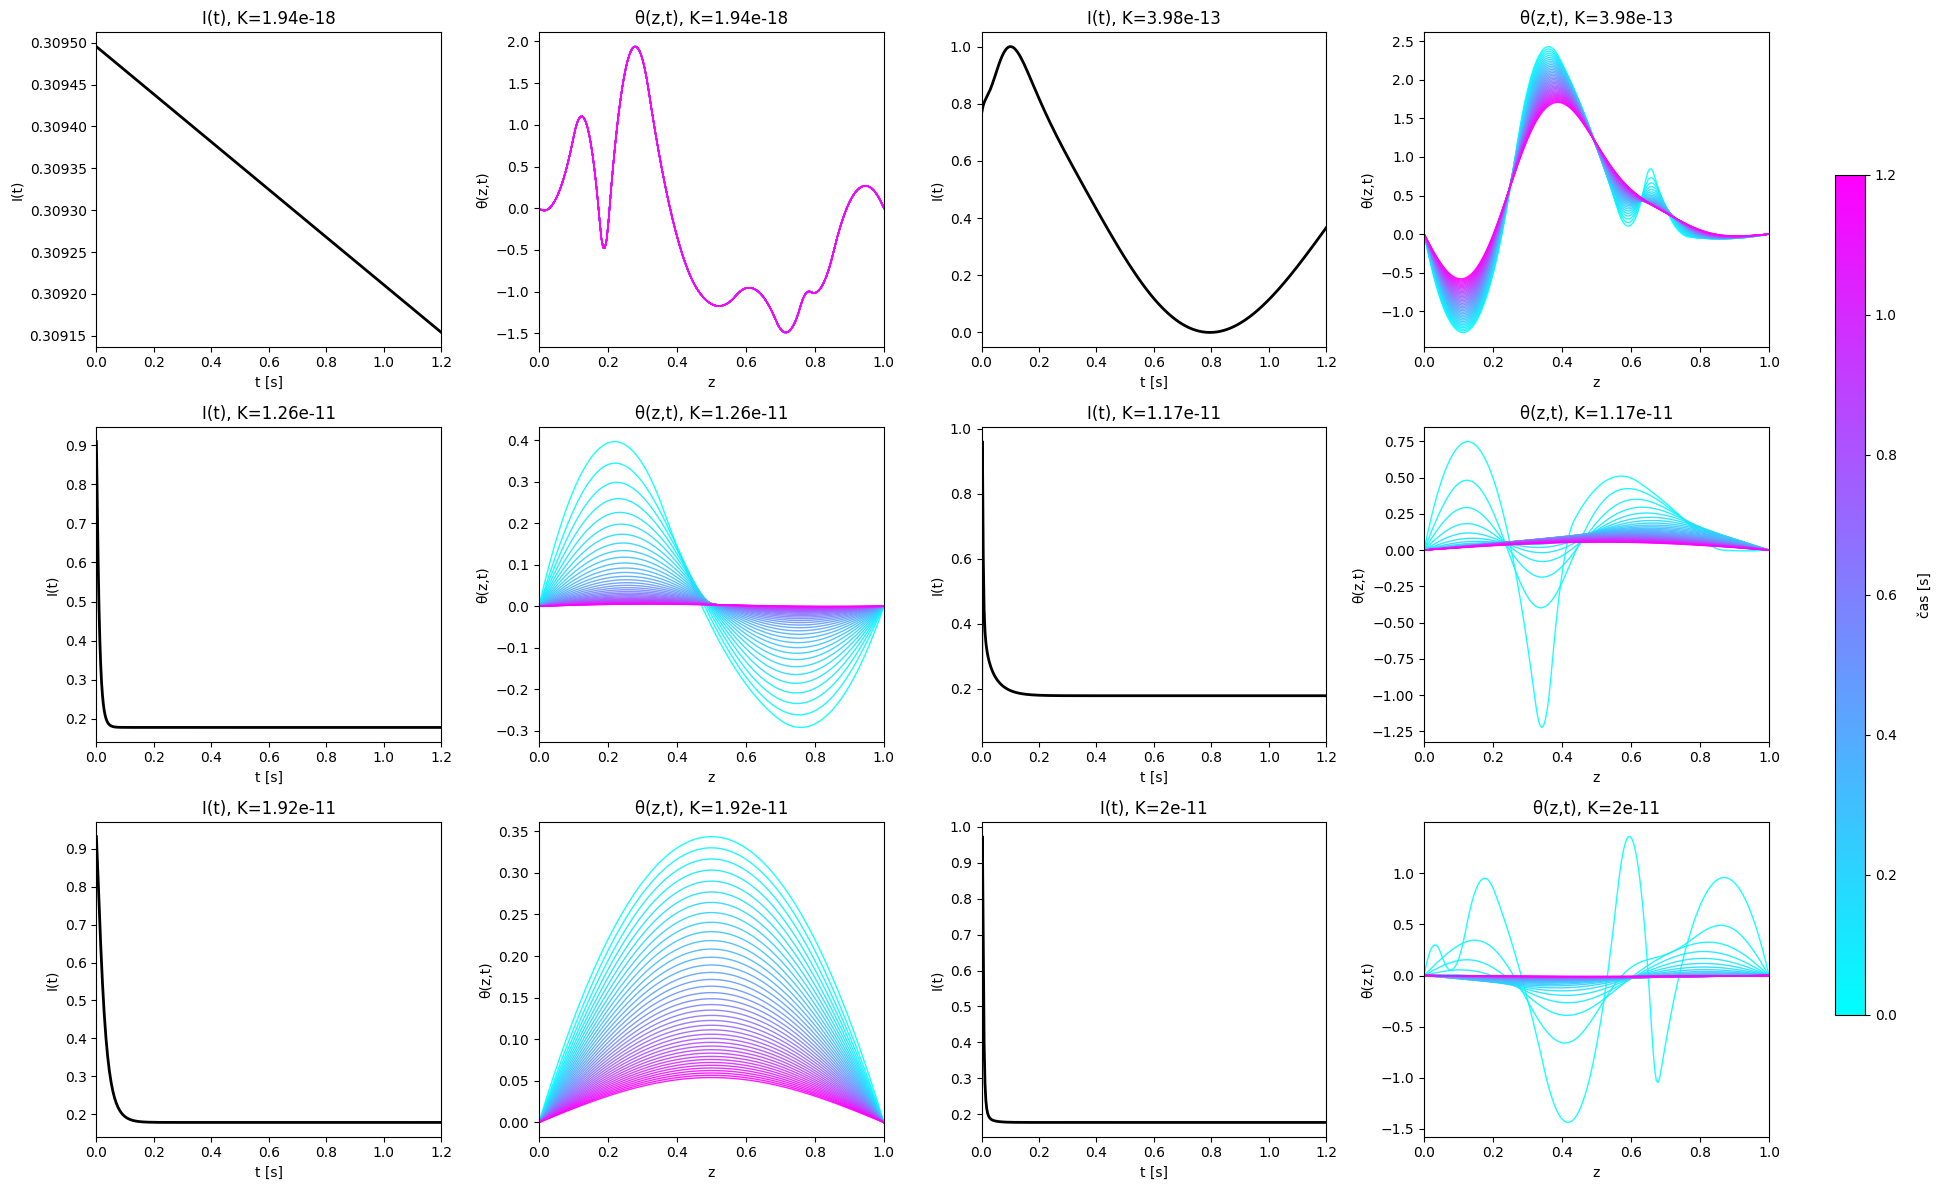

In [5]:
indices = [
    np.argmin(K),                                  # very small K
    np.where(K < np.percentile(K, 5))[0][10],      # small
    np.where(K > np.percentile(K, 25))[0][10],     # lower-mid
    np.where(K > np.percentile(K, 50))[0][10],     # median
    np.where(K > np.percentile(K, 75))[0][10],     # upper-mid
    np.argmax(K)                                   # largest K
]

print("Chosen K values:")
for idx in indices:
    print(f"  idx {idx}: K = {K[idx]:.3g}")

# --------------------------------
# COMPUTE θ(z,t) SERIES FOR ALL
# --------------------------------
gamma1 = 0.098
D = 10e-6
dt = 5e-6
num_steps = 20000
save_step = 500
z = np.linspace(0, 1, theta0.shape[1])

theta_all = []
for idx in indices:
    theta_series = theta_time_evolution(
        theta0[idx],
        K[idx] / gamma1,
        D=D,
        dt=dt,
        num_timesteps=num_steps,
        nth_step_save=save_step
    )
    theta_all.append(np.array(theta_series))

# --------------------------------
# COLOR MAP FOR TIME
# --------------------------------
cmap = get_cmap("cool")
n_frames = len(theta_all[0])
time_values = np.linspace(0, T, n_frames)
colors = cmap(np.linspace(0, 1, n_frames))

norm = Normalize(vmin=0, vmax=T)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# --------------------------------
# CREATE 3 × 4 FIGURE
# --------------------------------
fig, axes = plt.subplots(3, 4, figsize=(20, 12))

# --------------------------------
# PLOT IN GRID
# --------------------------------
for row in range(3):
    for col in range(2):  # two K's per row
        global_idx = row*2 + col
        idx = indices[global_idx]

        # LEFT COLUMN OF PAIR: I(t)
        ax_I = axes[row, 2*col]
        ax_I.plot(times, I[idx], lw=2, color="black")
        ax_I.set_title(f"I(t), K={K[idx]:.3g}")
        ax_I.set_xlabel("t [s]")
        ax_I.set_ylabel("I(t)")
        ax_I.set_xlim(0, T)

        # RIGHT COLUMN OF PAIR: θ(z,t)
        ax_theta = axes[row, 2*col + 1]
        for i in range(n_frames):
            ax_theta.plot(z, theta_all[global_idx][i], lw=1.0, color=colors[i], alpha=0.9)

        ax_theta.set_title(f"θ(z,t), K={K[idx]:.3g}")
        ax_theta.set_xlabel("z")
        ax_theta.set_ylabel("θ(z,t)")
        ax_theta.set_xlim(0,1)

# Colorbar on the right side OUTSIDE the grid
# --- First tighten subplots ---
plt.tight_layout(rect=[0, 0, 0.90, 1])  
#                               ^^^^^
# This reserves the RIGHT 10% of the figure for the colorbar

# --- Then add the colorbar in that reserved space ---
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("čas [s]", rotation=90, labelpad=15)

plt.savefig(os.getcwd() + "/figs/Int_cas_raz_K.pdf", format="pdf", bbox_inches="tight")
plt.show()